# Create multiple extension modules to a loading module for the biosynthesis of `Basidalin`

The RetroTide repository consists of two key packages - `bcs` and `retrotide`. The `bcs` package comprises key PKS domains (e.g. AT, DH, ER, KR) and their corresponding reaction rules, written as SMARTS templates with RDKit. These domains can then be concatenated together to form modules, which can in turn be concatenated together to form a chimeric type I PKS. Meanwhile, `retrotide` calls upon `bcs` to combinatorially explore the design space of chimeric type I PKSs with the objective of synthesizing a target molecule, or at least, its required carbon scaffold.

The introduction presented here is specifically for `bcs` rather than `retrotide`. Consequently, in building various PKS designs here, we specify the various starter and extender units as well as the domain architectures within a module. When using `retrotide`, however, we only need to provide a target molecule as the input, after which `retrotide` will recursively decide on the optimal choice of starters, extenders, and domain architectures to use in order to automatically design chimeric PKSs that produce molecules which are chemically similar to the specified target.

In [4]:
from retrotide import retrotide, structureDB

In [8]:
import bcs
from collections import OrderedDict
from rdkit import Chem

In [9]:
# import image module
from IPython.display import Image

# get the image
Image(url="basidalin_biopks.png", width=600, height=300)

SMILES: O=C([S])CO


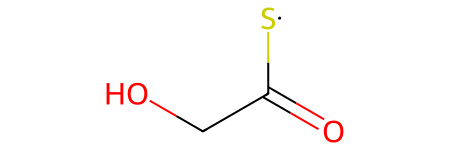

In [10]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

cluster = bcs.Cluster(modules = [loading_module])
mol = cluster.computeProduct(structureDB)

# Convert mol to SMILES
smiles = Chem.MolToSmiles(mol)
print("SMILES:", smiles)
mol

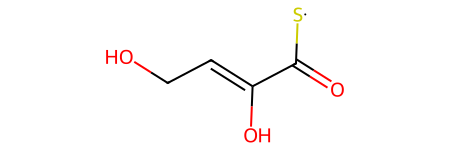

In [11]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

### first extension module with hydroxymalonyl-CoA + DH + KR domain
AT_domain_mod1 = bcs.AT(active = True, substrate = "hmal") 
KR_domain_mod1 = bcs.KR(active = True, type = "B1")
DH_domain_mod1 = bcs.DH(active = True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})

module1 = bcs.Module(domains = mod1_domains_dict, loading = False)

cluster = bcs.Cluster(modules = [loading_module, module1])
mol = cluster.computeProduct(structureDB)
mol

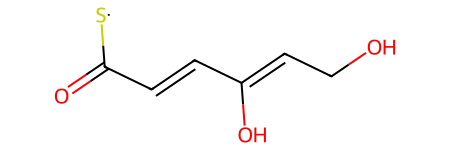

In [12]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

### first extension module with hydroxymalonyl-CoA + DH + KR domain
AT_domain_mod1 = bcs.AT(active = True, substrate = "hmal") 
KR_domain_mod1 = bcs.KR(active = True, type = "B1")
DH_domain_mod1 = bcs.DH(active = True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})

module1 = bcs.Module(domains = mod1_domains_dict, loading = False)

### second extension module with malonyl-CoA+ DH + KR domain
AT_domain_mod2 = bcs.AT(active = True, substrate = "Malonyl-CoA") 
DH_domain_mod2 = bcs.DH(active = True)
KR_domain_mod2 = bcs.KR(active = True, type = "B")
mod2_domains_dict = OrderedDict({bcs.AT: AT_domain_mod2,
                                 bcs.KR: KR_domain_mod2,
                                 bcs.DH: DH_domain_mod2,
                                 })

module2 = bcs.Module(domains = mod2_domains_dict, loading = False)

cluster = bcs.Cluster(modules = [loading_module, 
                                 module1,
                                 module2])

mol_wModule1_wModule2 = cluster.computeProduct(structureDB)
mol_wModule1_wModule2

SMILES: O=C1C=CC(=CCO)O1


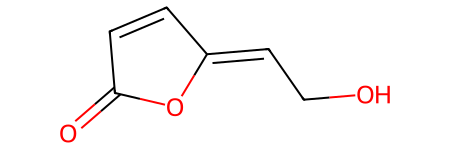

In [14]:
### add PKS release module TE
myTEobject = bcs.TE(active=True, cyclic=True, ring=1)
basidalin_mol_step1 = myTEobject.operation(mol_wModule1_wModule2)
# Convert mol to SMILES
basidalin_mol_step1_smiles = Chem.MolToSmiles(basidalin_mol_step1)
print("SMILES:", basidalin_mol_step1_smiles)
basidalin_mol_step1